# Entrega 3 — Modelagem, Validação e MLflow
**Projeto:** Classificação ESG por Machine Learning  
**Empresa:** NorthData Consulting  
**Dataset:** Public Company ESG Ratings  
**Autor:** Phelipe C. S. Cota  

---

## Estrutura do Notebook

| Etapa | Descrição |
|-------|-----------|
| i | Definição das Tarefas de ML e Variável Alvo |
| ii | Carregamento do Dataset Silver e Hold-Out Split |
| iii | Configuração do MLflow |
| iv | Pipeline Gold — Pré-processamento |
| v-A | Regressão — Previsão dos Scores ESG |
| v-B | Classificação — Previsão do Nível de Risco |
| vi | Análise e Apresentação dos Resultados |


---
## Etapa i — Definição das Tarefas de ML e Variável Alvo

### Contextualização

Este notebook implementa dois modelos de Machine Learning com objetivo de
classificar e avaliar o risco ESG de empresas fornecedoras, alimentando
diretamente os três produtos de BI do projeto: Matriz de Criticidade,
Mapa de Riscos e Dashboard de KPIs.

### Tarefa A — Regressão

**Objetivo:** Prever o valor numérico dos scores ESG em cada dimensão —
`environment_score`, `social_score` e `governance_score` — a partir de
características observáveis da empresa.

**Por que regressão?** Os scores são variáveis contínuas (números inteiros
em faixas amplas). Prever o valor exato nos permite calcular o `total_score`
como soma das três dimensões e, a partir dele, derivar o nível de risco.

**Variável alvo (target):** `environment_score`, `social_score` e
`governance_score` — treinados separadamente, um modelo por dimensão.

### Tarefa B — Classificação

**Objetivo:** Prever diretamente o nível de risco ESG (`risk_level`) da
empresa, classificando-a em três categorias criadas a partir do `total_score`.

**Regra de negócio para criação do `risk_level`:**

| Categoria | Critério |
|-----------|----------|
| Alto Risco | `total_score < 900` |
| Risco Moderado | `900 ≤ total_score ≤ 1150` |
| Baixo Risco | `total_score > 1150` |

**Features utilizadas em ambas as tarefas:**
`exchange`, `industry`, `revenue_M`, `employees`,
`environment_grade`, `social_grade`, `governance_grade`

> **Nota sobre Data Leakage:** As colunas `*_score`, `*_level`, `*_grade`
> do total e `last_processing_date` são excluídas das features por serem
> derivadas do target ou irrelevantes para a previsão. O `total_score` e
> `total_grade` seriam vazamento direto do target da classificação.


In [3]:
# ── Instalação e importações ─────────────────────────────────
# !pip install scikit-learn mlflow pandas numpy matplotlib seaborn

import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib

from sklearn.model_selection import (train_test_split, KFold,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score, recall_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

warnings.filterwarnings('ignore')
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

# ── Diretório raiz do projeto (independente de onde o Jupyter foi iniciado) ──
# __file__ não existe em notebooks; usamos Path.cwd() e subimos até encontrar
# a pasta raiz que contém 'data/', 'notebooks/' e 'mlruns/'
ROOT_DIR = Path.cwd()
# Sobe diretórios até encontrar a pasta 'data' (máx 4 níveis)
for _ in range(4):
    if (ROOT_DIR / 'data').exists():
        break
    ROOT_DIR = ROOT_DIR.parent

DATA_SILVER = ROOT_DIR / 'data' / 'silver' / 'data_silver.csv'
MLRUNS_URI  = f"file:///{(ROOT_DIR / 'mlruns').as_posix()}"


# ── Pasta para salvar modelos ─────────────────────────────────
MODELS_DIR = ROOT_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print(f"ROOT_DIR   : {ROOT_DIR}")
print(f"DATA_SILVER: {DATA_SILVER}")
print(f"MLRUNS_URI : {MLRUNS_URI}")
print(f"Arquivo existe: {DATA_SILVER.exists()}")

# ── Definição das features e targets ─────────────────────────
FEATURES = [
    'exchange',            # Bolsa de valores (NYSE ou NASDAQ)
    'industry',            # Setor de atuação da empresa
    'revenue_M',           # Faturamento anual em milhões USD
    'employees',           # Número total de funcionários
    'environment_grade',   # Nota ESG ambiental (C até AAA)
    'social_grade',        # Nota ESG social (C até AAA)
    'governance_grade',    # Nota ESG de governança (C até AAA)
]

TARGETS_REG = ['environment_score', 'social_score', 'governance_score']
TARGET_CLF  = 'risk_level'

print("Configuração definida:")
print(f"  Features ({len(FEATURES)}): {FEATURES}")
print(f"  Targets regressão: {TARGETS_REG}")
print(f"  Target classificação: {TARGET_CLF}")


ROOT_DIR   : d:\Trabalho\Ciência de Dados\Material\Projetos III\NorthData-Consulting-Classific-ESG-por-Machine-Learning
DATA_SILVER: d:\Trabalho\Ciência de Dados\Material\Projetos III\NorthData-Consulting-Classific-ESG-por-Machine-Learning\data\silver\data_silver.csv
MLRUNS_URI : file:///d:/Trabalho/Ciência de Dados/Material/Projetos III/NorthData-Consulting-Classific-ESG-por-Machine-Learning/mlruns
Arquivo existe: True
Configuração definida:
  Features (7): ['exchange', 'industry', 'revenue_M', 'employees', 'environment_grade', 'social_grade', 'governance_grade']
  Targets regressão: ['environment_score', 'social_score', 'governance_score']
  Target classificação: risk_level


---
## Etapa ii — Carregamento do Dataset Silver e Hold-Out Split

### Por que o split vem ANTES de qualquer transformação?

Imagine que você está preparando um exame para avaliar um aluno.
A regra é simples: o aluno não pode ver as questões antes da prova.

Em Machine Learning, o equivalente é o **Data Leakage** (vazamento de dados).
Se normalizarmos os dados antes de dividir, o `StandardScaler` aprenderá
a média e o desvio padrão do dataset inteiro — incluindo os dados de teste.
O modelo "trapacearia" usando informações que não deveria ter acesso.

**A ordem correta é sempre:**
1. Dividir em treino e teste (Hold-Out)
2. Aprender os parâmetros de transformação **apenas no treino**
3. Aplicar a mesma transformação no teste

### Estratégia de Split

**Regressão:** `KFold` simples — o target é contínuo, sem classes para estratificar.

**Classificação:** `StratifiedKFold` — garante que a proporção das três
classes de risco seja mantida tanto no treino quanto no teste.
Sem isso, a classe "Baixo Risco" (23% do dataset) poderia estar
sub-representada em alguma fatia.


In [4]:
# ── Carregar dataset Silver atualizado ──────────────────────
df = pd.read_csv(DATA_SILVER)
print(f"Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Colunas: {df.columns.tolist()}")

# ── Criar variável alvo da classificação ─────────────────────
# Regra de negócio definida pelo cliente (EdenRed)
df[TARGET_CLF] = pd.cut(
    df['total_score'],
    bins=[-1, 899, 1150, 9999],
    labels=['Alto Risco', 'Risco Moderado', 'Baixo Risco']
)

print(f"\nDistribuição do risk_level criado:")
print(df[TARGET_CLF].value_counts())
print(f"\nPercentuais:")
print(df[TARGET_CLF].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# ── Separar features e targets ───────────────────────────────
X = df[FEATURES].copy()

y_env = df['environment_score']
y_soc = df['social_score']
y_gov = df['governance_score']
y_clf = df[TARGET_CLF]

# ── Hold-Out Split ───────────────────────────────────────────
# Regressão: random_state=42 garante reprodutibilidade
X_train_r, X_test_r, y_env_train, y_env_test = train_test_split(
    X, y_env, test_size=0.30, random_state=42)
_, _, y_soc_train, y_soc_test = train_test_split(
    X, y_soc, test_size=0.30, random_state=42)
_, _, y_gov_train, y_gov_test = train_test_split(
    X, y_gov, test_size=0.30, random_state=42)

# Classificação: stratify preserva proporção das classes
X_train_c, X_test_c, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

print(f"\n{'Split':30s} {'Treino':>8} {'Teste':>8}")
print("-" * 48)
print(f"{'Regressão':30s} {X_train_r.shape[0]:>8} {X_test_r.shape[0]:>8}")
print(f"{'Classificação (stratified)':30s} {X_train_c.shape[0]:>8} {X_test_c.shape[0]:>8}")

print(f"\nProporção risk_level no treino:")
print((y_clf_train.value_counts(normalize=True)*100).round(1))
print(f"\nProporção risk_level no teste:")
print((y_clf_test.value_counts(normalize=True)*100).round(1))


Dataset carregado: 722 linhas × 20 colunas
Colunas: ['cik', 'ticker', 'name', 'exchange', 'industry', 'revenue_M', 'employees', 'environment_grade', 'environment_level', 'environment_score', 'social_grade', 'social_level', 'social_score', 'governance_grade', 'governance_level', 'governance_score', 'total_grade', 'total_level', 'total_score', 'last_processing_date']

Distribuição do risk_level criado:
risk_level
Risco Moderado    285
Alto Risco        271
Baixo Risco       166
Name: count, dtype: int64

Percentuais:
risk_level
Risco Moderado    39.5%
Alto Risco        37.5%
Baixo Risco       23.0%
Name: proportion, dtype: object

Split                            Treino    Teste
------------------------------------------------
Regressão                           505      217
Classificação (stratified)          505      217

Proporção risk_level no treino:
risk_level
Risco Moderado    39.4
Alto Risco        37.6
Baixo Risco       23.0
Name: proportion, dtype: float64

Proporção risk_level

---
## Etapa iii — Configuração do MLflow

### O que é o MLflow e por que usamos?

O MLflow é uma plataforma de MLOps que resolve um problema clássico:
*"Na minha máquina funciona"*. Sem rastreamento, é impossível saber
qual combinação de hiperparâmetros gerou o melhor resultado.

O MLflow registra automaticamente (via `autolog`) ou manualmente:
- Parâmetros dos modelos (ex: `n_estimators=200`)
- Métricas de avaliação (MAE, F1-Score)
- O modelo treinado serializado (arquivo `.pkl`)
- Artefatos como gráficos e arquivos CSV

### Nomenclatura dos experimentos

Os experimentos anteriores (`esg_regression` e `esg_classification`) são
preservados. Criamos experimentos novos com sufixo `_v2` para isolar
completamente esta entrega, facilitando a comparação histórica no dashboard
do MLflow.


In [5]:
# ── Configurar MLflow ────────────────────────────────────────
# MLFLOW_ALLOW_FILE_STORE já definido na célula de importações
mlflow.set_tracking_uri(MLRUNS_URI)

# Criar experimentos isolados (não conflita com runs anteriores)
EXP_REG = mlflow.set_experiment("esg_regression_v2")
EXP_CLF = mlflow.set_experiment("esg_classification_v2")

print(f"Experimento regressão:      {EXP_REG.name} (id={EXP_REG.experiment_id})")
print(f"Experimento classificação:  {EXP_CLF.name} (id={EXP_CLF.experiment_id})")
print("\nMLflow configurado. Todos os treinos serão rastreados automaticamente.")
print("Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000")


2026/06/09 17:02:59 INFO mlflow.tracking.fluent: Experiment with name 'esg_regression_v2' does not exist. Creating a new experiment.
2026/06/09 17:02:59 INFO mlflow.tracking.fluent: Experiment with name 'esg_classification_v2' does not exist. Creating a new experiment.


Experimento regressão:      esg_regression_v2 (id=952532686155448844)
Experimento classificação:  esg_classification_v2 (id=833186244202153480)

MLflow configurado. Todos os treinos serão rastreados automaticamente.
Para visualizar: execute 'mlflow ui' no terminal e acesse http://localhost:5000


---
## Etapa iv — Pipeline Gold: Pré-processamento de Features

### Por que precisamos transformar os dados?

Os algoritmos de Machine Learning falam a linguagem dos números.
Textos como "Technology" ou "NYSE" precisam ser convertidos.
Além disso, alguns algoritmos são sensíveis à escala — um faturamento
de US$ 500 bilhões pode dominar completamente um score de 0 a 700
se não normalizarmos.

### As 3 transformações aplicadas

**A. OrdinalEncoder para grades (hierarquia clara)**

Os grades (C, B, BB, BBB, A, AA, AAA) têm uma ordem lógica progressiva.
"AA" é matematicamente superior a "B". O `OrdinalEncoder` converte
respeitando essa hierarquia: `C=0, B=3, BB=4, BBB=5, A=6, AA=7, AAA=8`.

> Não usamos `OneHotEncoder` aqui porque ele perderia a informação de ordem.

**B. OneHotEncoder para industry e exchange (sem hierarquia)**

"Technology" não vale mais que "Healthcare". Não existe hierarquia.
Usar números sequenciais (1=Tech, 2=Health...) induziria o modelo a
assumir falsamente que um setor é "maior" que outro.
O `OneHotEncoder` cria uma coluna binária para cada categoria.

**C. StandardScaler para revenue_M e employees (escala)**

O KNN calcula distâncias entre pontos. Se `revenue_M` vai de 0 a 572.754
e `employees` de 20 a 2.300.000, o KNN ignora o segundo em comparação
com o primeiro. O `StandardScaler` coloca ambos na mesma escala
(média=0, desvio=1), dando chance igual a cada feature.

> **Importante:** O `StandardScaler` é ajustado (`fit`) apenas nos dados
> de treino e depois apenas aplicado (`transform`) nos dados de teste.


In [6]:
# ── Pipeline Gold — ColumnTransformer ───────────────────────
# Ordem completa de grades (C ao AAA) definida explicitamente
# para evitar erro com categorias raras (ex: CCC aparece em social_grade)
GRADE_ORDER = ['C', 'CC', 'CCC', 'B', 'BB', 'BBB', 'A', 'AA', 'AAA']

preprocessor = ColumnTransformer(transformers=[

    # A. Categóricas ordinais — respeitam hierarquia de qualidade ESG
    ('ord', OrdinalEncoder(
        categories=[GRADE_ORDER, GRADE_ORDER, GRADE_ORDER],
        handle_unknown='use_encoded_value',
        unknown_value=-1           # grades desconhecidos viram -1
    ), ['environment_grade', 'social_grade', 'governance_grade']),

    # B. Categóricas nominais — sem hierarquia entre setores/bolsas
    ('ohe', OneHotEncoder(
        handle_unknown='ignore',   # setores novos viram vetor de zeros
        sparse_output=False
    ), ['exchange', 'industry']),

    # C. Numéricas contínuas — escalonamento para KNN
    ('num', StandardScaler(),
     ['revenue_M', 'employees']),

], remainder='drop')   # descarta qualquer coluna não listada

# ── Testar o preprocessador (fit no treino, transform nos dois) ──
X_train_proc = preprocessor.fit_transform(X_train_r)
X_test_proc  = preprocessor.transform(X_test_r)

# Mostrar dimensões após one-hot (expande colunas de indústria)
ohe_cols = preprocessor.named_transformers_['ohe'].get_feature_names_out(
    ['exchange', 'industry'])
total_features = 3 + len(ohe_cols) + 2  # ord + ohe + num

print(f"Features originais:          {len(FEATURES)}")
print(f"Features após pré-processamento: {total_features}")
print(f"  └─ OrdinalEncoder:    3 colunas (grades E, S, G)")
print(f"  └─ OneHotEncoder:    {len(ohe_cols)} colunas (exchange + industry)")
print(f"  └─ StandardScaler:   2 colunas (revenue_M, employees)")
print(f"\nShape treino: {X_train_proc.shape}")
print(f"Shape teste:  {X_test_proc.shape}")
print("\nPreprocessador validado — sem data leakage.")


Features originais:          7
Features após pré-processamento: 51
  └─ OrdinalEncoder:    3 colunas (grades E, S, G)
  └─ OneHotEncoder:    46 colunas (exchange + industry)
  └─ StandardScaler:   2 colunas (revenue_M, employees)

Shape treino: (505, 51)
Shape teste:  (217, 51)

Preprocessador validado — sem data leakage.


---
## Etapa v-A — Regressão: Previsão dos Scores ESG

### Modelos avaliados e motivação da escolha

**KNN (K-Nearest Neighbors)**
Classifica uma nova empresa buscando as K empresas mais similares
no espaço das features e calculando a média dos scores delas.
Simples e interpretável, mas sensível à escala — por isso exige
o `StandardScaler` aplicado na etapa anterior.
Hiperparâmetros avaliados: `n_neighbors` ∈ {3,5,7,9},
`weights` ∈ {uniform, distance}, `metric` ∈ {euclidean, manhattan}.

**Decision Tree (Árvore de Decisão)**
Cria uma sequência de perguntas binárias sobre as features
(ex: "O grade ambiental é ≥ A?") até isolar grupos de empresas
com scores similares. Altamente interpretável — as regras podem
ser exibidas para gestores. Risco: overfitting quando a árvore
fica profunda demais (decora os dados).
Hiperparâmetros: `max_depth` ∈ {3,5,7,10,None},
`min_samples_split` ∈ {2,5,10}, `min_samples_leaf` ∈ {1,2,4}.

**Random Forest**
Um comitê de centenas de Árvores de Decisão independentes,
cada uma treinada em uma amostra diferente dos dados e votando
na resposta final. Resolve o overfitting da árvore individual
ao fazer a média das previsões. Esperamos que seja o modelo
vencedor nessa tarefa.
Hiperparâmetros: `n_estimators` ∈ {50,100,200},
`max_depth` ∈ {5,10,None}, `min_samples_split` ∈ {2,5}.

### Estratégia de validação

O `GridSearchCV` com `KFold(n_splits=5)` testa todas as combinações
de hiperparâmetros usando validação cruzada no conjunto de treino.
A métrica de seleção é `neg_mean_absolute_error` — penaliza
previsões que erram muito o valor real do score.


In [7]:
# ── Configuração dos modelos de regressão ────────────────────
modelos_reg = {
    'KNN': {
        'model': KNeighborsRegressor(),
        'grid': {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights':     ['uniform', 'distance'],
            'model__metric':      ['euclidean', 'manhattan']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'grid': {
            'model__max_depth':        [3, 5, 7, 10, None],
            'model__min_samples_split':[2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'grid': {
            'model__n_estimators':     [50, 100, 200],
            'model__max_depth':        [5, 10, None],
            'model__min_samples_split':[2, 5]
        }
    }
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Modelos e grids configurados.")
print(f"KFold: 5 folds | scoring: neg_mean_absolute_error")


Modelos e grids configurados.
KFold: 5 folds | scoring: neg_mean_absolute_error


In [8]:
# ── Treinamento com MLflow ────────────────────────────────────
mlflow.set_experiment("esg_regression_v2")

resultados_reg = {}

for target_name, y_train, y_test in [
    ('environment_score', y_env_train, y_env_test),
    ('social_score',      y_soc_train, y_soc_test),
    ('governance_score',  y_gov_train, y_gov_test)
]:
    print(f"\n{'='*55}")
    print(f"  Target: {target_name}")
    print(f"{'='*55}")
    resultados_reg[target_name] = {}

    for nome, cfg in modelos_reg.items():

        # Pipeline completo: preprocessador + modelo
        pipe = Pipeline([
            ('pre',   preprocessor),
            ('model', cfg['model'])
        ])

        # Grid Search com validação cruzada
        gs = GridSearchCV(
            pipe, cfg['grid'],
            cv=kf,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            refit=True        # retreina com melhores params no treino inteiro
        )

        # MLflow: abre um run, treina, registra tudo
        with mlflow.start_run(run_name=f"{nome}_{target_name}"):
            gs.fit(X_train_r, y_train)
            y_pred = gs.best_estimator_.predict(X_test_r)

            mae  = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2   = r2_score(y_test, y_pred)

            # Registrar no MLflow
            mlflow.log_param('target', target_name)
            mlflow.log_params(gs.best_params_)
            mlflow.log_metric('MAE',  mae)
            mlflow.log_metric('RMSE', rmse)
            mlflow.log_metric('R2',   r2)
            mlflow.log_metric('best_cv_mae', -gs.best_score_)
            joblib.dump(gs.best_estimator_, MODELS_DIR / f"{nome}_{target_name}.pkl")
            mlflow.sklearn.log_model(gs.best_estimator_, "model")

        resultados_reg[target_name][nome] = {
            'MAE':  round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2':   round(r2, 4),
            'best_params': gs.best_params_
        }

        print(f"  {nome:15s} | MAE={mae:7.2f} | RMSE={rmse:7.2f} | R²={r2:.4f}")
        print(f"  {'':15s}   Melhores params: {gs.best_params_}")

print("\nTodos os runs de regressão registrados no MLflow.")



  Target: environment_score


2026/06/09 17:03:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:03:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  KNN             | MAE=  29.17 | RMSE=  41.85 | R²=0.9179
                    Melhores params: {'model__metric': 'euclidean', 'model__n_neighbors': 9, 'model__weights': 'distance'}


2026/06/09 17:03:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:03:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Decision Tree   | MAE=  22.81 | RMSE=  27.89 | R²=0.9635
                    Melhores params: {'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


...

  KNN             | MAE=  19.88 | RMSE=  32.16 | R²=0.5619
                    Melhores params: {'model__metric': 'manhattan', 'model__n_neighbors': 9, 'model__weights': 'distance'}


2026/06/09 17:03:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:03:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Decision Tree   | MAE=  16.70 | RMSE=  24.62 | R²=0.7433
                    Melhores params: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}


2026/06/09 17:04:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:04:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Random Forest   | MAE=  16.11 | RMSE=  24.00 | R²=0.7560
                    Melhores params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Todos os runs de regressão registrados no MLflow.


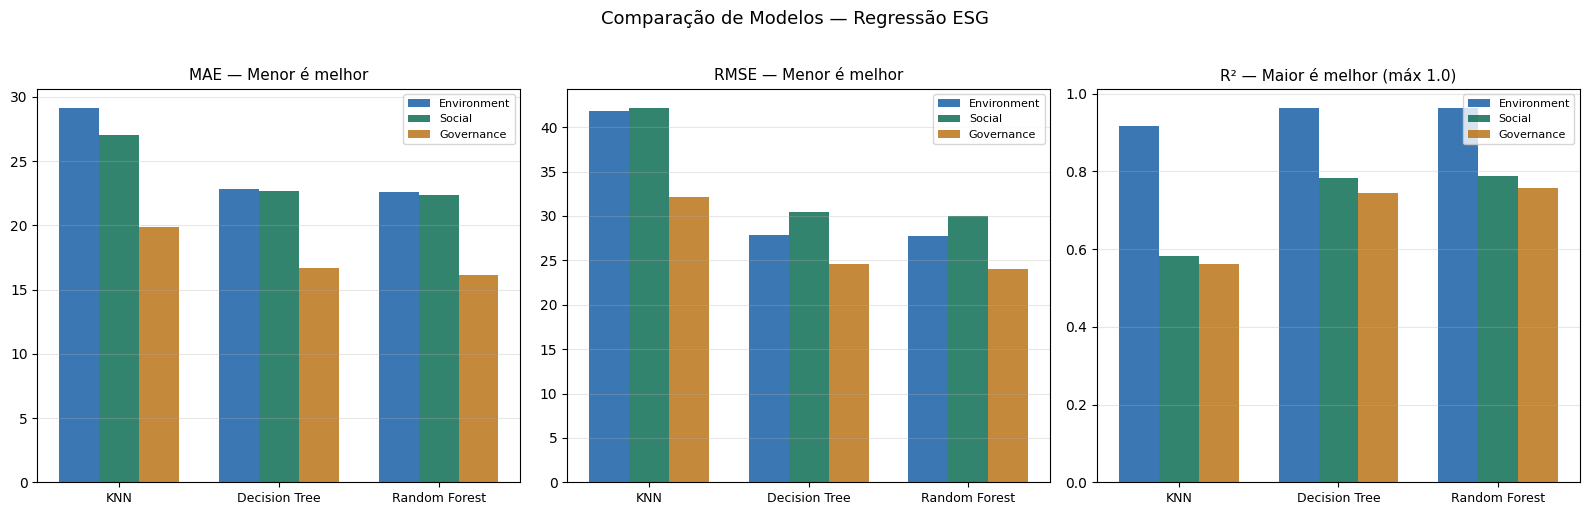

Gráfico salvo: regressao_comparacao.png


In [9]:
# ── Visualização: tabela comparativa de regressão ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = ['MAE', 'RMSE', 'R2']
titulos  = ['MAE — Menor é melhor',
            'RMSE — Menor é melhor',
            'R² — Maior é melhor (máx 1.0)']
cores = ['#185FA5', '#0F6E56', '#BA7517']

for ax, metrica, titulo in zip(axes, metricas, titulos):
    dados = {t: [resultados_reg[t][m][metrica] for m in modelos_reg]
             for t in TARGETS_REG}
    x = np.arange(len(modelos_reg))
    w = 0.25
    for i, (target, vals) in enumerate(dados.items()):
        label = target.replace('_score','').capitalize()
        ax.bar(x + i*w, vals, w, label=label, color=cores[i], alpha=0.85)
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(x + w)
    ax.set_xticklabels(list(modelos_reg.keys()), fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparação de Modelos — Regressão ESG', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('regressao_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: regressao_comparacao.png")


---
## Etapa v-B — Classificação: Previsão do Nível de Risco ESG

### Adaptações em relação à regressão

**`StratifiedKFold` em vez de `KFold`**

A classe "Baixo Risco" representa 23% do dataset. Com `KFold` simples,
poderíamos ter um fold onde "Baixo Risco" está sub-representado — o modelo
aprenderia mal essa classe. O `StratifiedKFold` garante que cada fold
tenha a mesma proporção das três classes.

**`class_weight='balanced'` em Decision Tree e Random Forest**

Mesmo com distribuição razoável, o modelo tende a "preguiçar" na classe
menos frequente. O parâmetro `balanced` faz o modelo dar mais atenção
às classes menores, ponderando os erros inversamente proporcional à frequência.

**Métrica de seleção: `f1_macro`**

A acurácia simples seria enganosa — um modelo que sempre diz "Risco Moderado"
teria ~39% de acurácia sem aprender nada. O `F1-Macro` calcula o F1-Score
de cada classe separadamente e tira a média, penalizando o modelo que
ignora classes menores.


In [10]:
# ── Configuração dos modelos de classificação ─────────────────
modelos_clf = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'grid': {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights':     ['uniform', 'distance'],
            'model__metric':      ['euclidean', 'manhattan']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'   # atenção extra à classe minoritária
        ),
        'grid': {
            'model__max_depth':        [3, 5, 7, 10, None],
            'model__min_samples_split':[2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        'grid': {
            'model__n_estimators':     [50, 100, 200],
            'model__max_depth':        [5, 10, None],
            'model__min_samples_split':[2, 5]
        }
    }
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Modelos e grids configurados.")
print("StratifiedKFold: 5 folds | scoring: f1_macro")


Modelos e grids configurados.
StratifiedKFold: 5 folds | scoring: f1_macro


In [11]:
# ── Treinamento com MLflow ────────────────────────────────────
mlflow.set_experiment("esg_classification_v2")

resultados_clf = {}
ORDER = ['Alto Risco', 'Risco Moderado', 'Baixo Risco']

for nome, cfg in modelos_clf.items():

    pipe = Pipeline([
        ('pre',   preprocessor),
        ('model', cfg['model'])
    ])

    gs = GridSearchCV(
        pipe, cfg['grid'],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        refit=True
    )

    with mlflow.start_run(run_name=f"{nome}_risk_level"):
        gs.fit(X_train_c, y_clf_train)
        y_pred = gs.best_estimator_.predict(X_test_c)

        f1_mac   = f1_score(y_clf_test, y_pred, average='macro')
        rec_alto = recall_score(y_clf_test, y_pred,
                                labels=['Alto Risco'], average='macro')
        acc      = accuracy_score(y_clf_test, y_pred)
        cm       = confusion_matrix(y_clf_test, y_pred, labels=ORDER)

        mlflow.log_params(gs.best_params_)
        mlflow.log_metric('F1_Macro',          f1_mac)
        mlflow.log_metric('Recall_Alto_Risco', rec_alto)
        mlflow.log_metric('Accuracy',          acc)
        mlflow.log_metric('best_cv_f1',        gs.best_score_)
        joblib.dump(gs.best_estimator_, MODELS_DIR / f"{nome}_risk_level.pkl")
        mlflow.sklearn.log_model(gs.best_estimator_, "model")

    resultados_clf[nome] = {
        'F1_Macro':   round(f1_mac, 4),
        'Recall_Alto':round(rec_alto, 4),
        'Accuracy':   round(acc, 4),
        'CM':         cm,
        'best_params':gs.best_params_
    }

    print(f"\n{nome}")
    print(f"  F1-Macro={f1_mac:.4f} | Recall-Alto={rec_alto:.4f} | Acc={acc:.4f}")
    print(f"  Melhores params: {gs.best_params_}")
    print(f"  Relatório:\n{classification_report(y_clf_test, y_pred, target_names=ORDER)}")

print("Todos os runs de classificação registrados no MLflow.")


2026/06/09 17:04:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:04:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



KNN
  F1-Macro=0.7114 | Recall-Alto=0.9753 | Acc=0.7558
  Melhores params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
  Relatório:
                precision    recall  f1-score   support

    Alto Risco       0.96      0.98      0.97        81
Risco Moderado       0.53      0.40      0.45        50
   Baixo Risco       0.67      0.76      0.71        86

      accuracy                           0.76       217
     macro avg       0.72      0.71      0.71       217
  weighted avg       0.75      0.76      0.75       217



2026/06/09 17:04:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:04:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Decision Tree
  F1-Macro=0.7928 | Recall-Alto=0.9877 | Acc=0.8157
  Melhores params: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
  Relatório:
                precision    recall  f1-score   support

    Alto Risco       0.96      0.99      0.98        81
Risco Moderado       0.63      0.64      0.63        50
   Baixo Risco       0.78      0.76      0.77        86

      accuracy                           0.82       217
     macro avg       0.79      0.79      0.79       217
  weighted avg       0.81      0.82      0.82       217



2026/06/09 17:04:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 17:04:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest
  F1-Macro=0.7901 | Recall-Alto=0.9506 | Acc=0.8018
  Melhores params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
  Relatório:
                precision    recall  f1-score   support

    Alto Risco       0.97      0.95      0.96        81
Risco Moderado       0.60      0.78      0.68        50
   Baixo Risco       0.79      0.67      0.73        86

      accuracy                           0.80       217
     macro avg       0.79      0.80      0.79       217
  weighted avg       0.82      0.80      0.80       217

Todos os runs de classificação registrados no MLflow.


---
## Etapa vi — Análise e Apresentação dos Resultados

### Seção do Relatório

---

#### 3. Modelos Avaliados

##### KNN (K-Nearest Neighbors)
Motivação: algoritmo intuitivo baseado em similaridade — empresas com
características parecidas tendem a ter scores ESG parecidos. Exige
padronização (`StandardScaler`) pois calcula distâncias euclidianas.
Grid Search avaliou `n_neighbors` ∈ {3,5,7,9}, `weights` ∈ {uniform, distance}
e `metric` ∈ {euclidean, manhattan}.

##### Decision Tree (Árvore de Decisão)
Motivação: altamente interpretável — as regras de decisão podem ser
traduzidas em critérios de negócio para os gestores da EdenRed.
Grid Search avaliou `max_depth` ∈ {3,5,7,10,None}, `min_samples_split` ∈ {2,5,10}
e `min_samples_leaf` ∈ {1,2,4}. O controle de profundidade previne overfitting.

##### Random Forest
Motivação: resolve o overfitting da Árvore de Decisão ao agregar votos
de centenas de árvores independentes. Grid Search avaliou `n_estimators` ∈ {50,100,200},
`max_depth` ∈ {5,10,None} e `min_samples_split` ∈ {2,5}.

---

#### 4. Comparação dos Modelos

Veja as tabelas e gráficos abaixo.

---

#### 5. Integração com MLflow

Experimentos criados:
- `esg_regression_v2` — 9 runs (3 modelos × 3 targets)
- `esg_classification_v2` — 3 runs (3 modelos × 1 target)

Registrado por run: parâmetros do modelo, métricas (MAE/RMSE/R²/F1),
modelo serializado e melhor score de validação cruzada.


In [12]:
# ── Tabela comparativa — Regressão ───────────────────────────
print("=" * 65)
print("REGRESSÃO — Comparação de métricas no conjunto de teste")
print("=" * 65)
print(f"{'Target':<22} {'Modelo':<17} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("-" * 65)
for target in TARGETS_REG:
    for modelo in modelos_reg:
        m = resultados_reg[target][modelo]
        print(f"{target:<22} {modelo:<17} {m['MAE']:>7.2f} {m['RMSE']:>7.2f} {m['R2']:>7.4f}")
    print()

print("=" * 55)
print("CLASSIFICAÇÃO — Comparação de métricas no teste")
print("=" * 55)
print(f"{'Modelo':<17} {'F1-Macro':>10} {'Recall-Alto':>12} {'Acurácia':>10}")
print("-" * 55)
for modelo, m in resultados_clf.items():
    print(f"{modelo:<17} {m['F1_Macro']:>10.4f} {m['Recall_Alto']:>12.4f} {m['Accuracy']:>10.4f}")


REGRESSÃO — Comparação de métricas no conjunto de teste
Target                 Modelo                MAE    RMSE      R²
-----------------------------------------------------------------
environment_score      KNN                 29.17   41.85  0.9179
environment_score      Decision Tree       22.81   27.89  0.9635
environment_score      Random Forest       22.59   27.69  0.9641

social_score           KNN                 27.05   42.21  0.5819
social_score           Decision Tree       22.68   30.49  0.7819
social_score           Random Forest       22.33   29.97  0.7892

governance_score       KNN                 19.88   32.16  0.5619
governance_score       Decision Tree       16.70   24.62  0.7433
governance_score       Random Forest       16.11   24.00  0.7560

CLASSIFICAÇÃO — Comparação de métricas no teste
Modelo              F1-Macro  Recall-Alto   Acurácia
-------------------------------------------------------
KNN                   0.7114       0.9753     0.7558
Decision Tree  

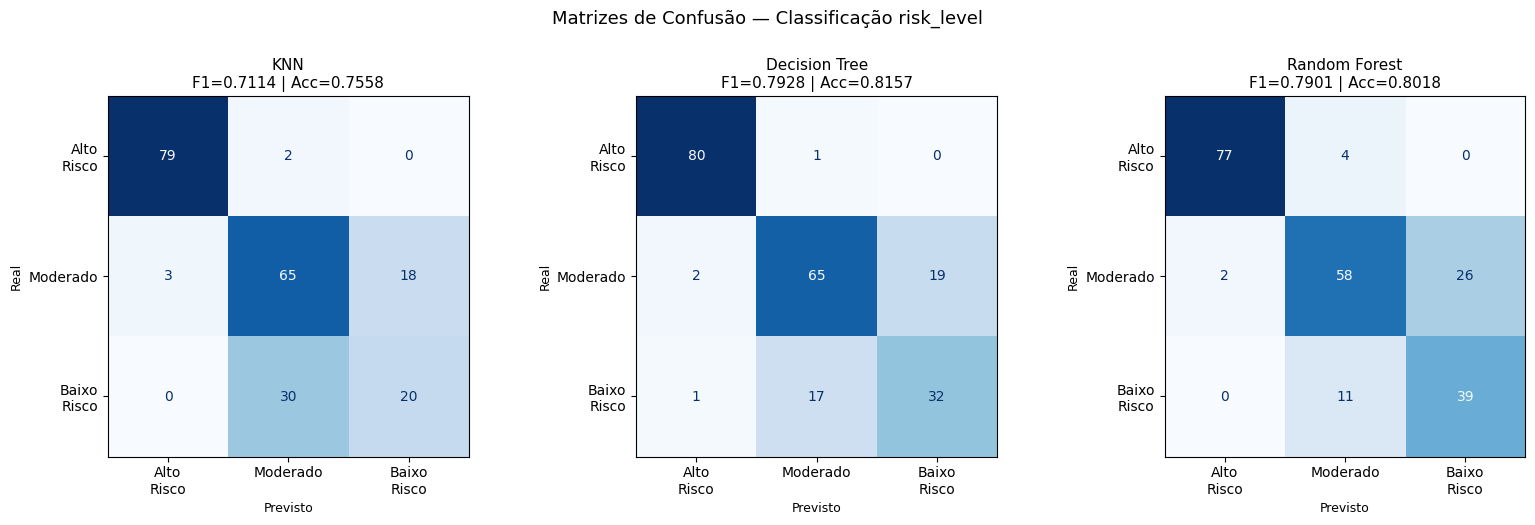

Gráfico salvo: classificacao_confusion_matrix.png


In [13]:
# ── Matrizes de confusão — Classificação ─────────────────────
ORDER = ['Alto Risco', 'Risco Moderado', 'Baixo Risco']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nome, m) in zip(axes, resultados_clf.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=m['CM'],
        display_labels=['Alto\nRisco', 'Moderado', 'Baixo\nRisco'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nome}\nF1={m['F1_Macro']:.4f} | Acc={m['Accuracy']:.4f}",
                 fontsize=11)
    ax.set_xlabel('Previsto', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.suptitle('Matrizes de Confusão — Classificação risk_level', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('classificacao_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: classificacao_confusion_matrix.png")


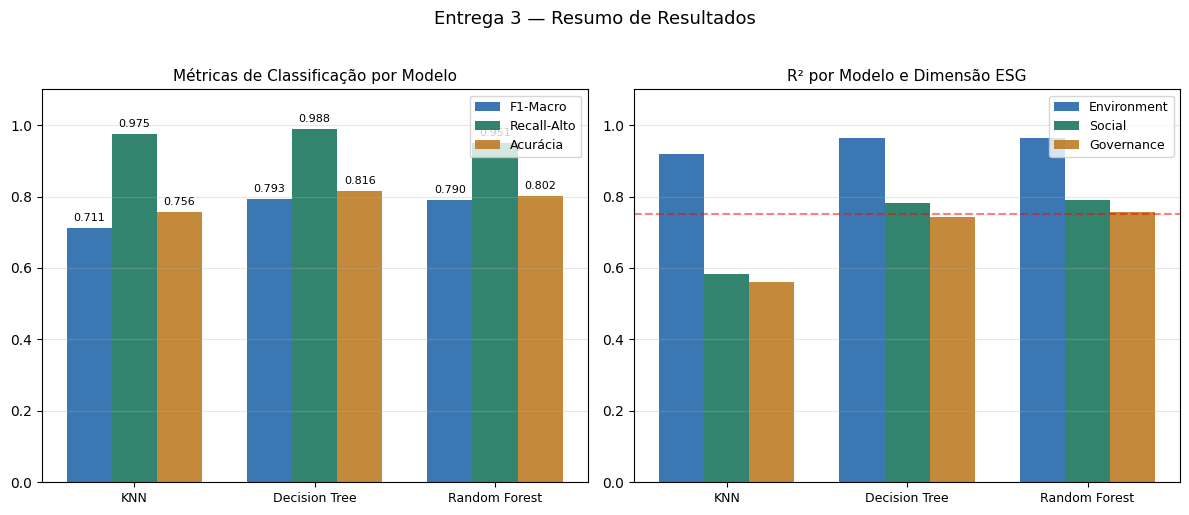

In [14]:
# ── Gráfico comparativo F1-Macro ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nomes  = list(resultados_clf.keys())
f1s    = [resultados_clf[n]['F1_Macro']    for n in nomes]
recalls= [resultados_clf[n]['Recall_Alto'] for n in nomes]
accs   = [resultados_clf[n]['Accuracy']    for n in nomes]
cores  = ['#185FA5', '#0F6E56', '#BA7517']

x = np.arange(len(nomes))
w = 0.25

# Gráfico 1: F1-Macro, Recall-Alto, Accuracy
axes[0].bar(x - w,  f1s,     w, label='F1-Macro',     color=cores[0], alpha=0.85)
axes[0].bar(x,      recalls, w, label='Recall-Alto',   color=cores[1], alpha=0.85)
axes[0].bar(x + w,  accs,    w, label='Acurácia',      color=cores[2], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nomes, fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=9)
axes[0].set_title('Métricas de Classificação por Modelo', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
for xi, (f, r, a) in enumerate(zip(f1s, recalls, accs)):
    axes[0].text(xi - w, f + 0.02, f'{f:.3f}', ha='center', fontsize=8)
    axes[0].text(xi,     r + 0.02, f'{r:.3f}', ha='center', fontsize=8)
    axes[0].text(xi + w, a + 0.02, f'{a:.3f}', ha='center', fontsize=8)

# Gráfico 2: R² comparativo para regressão
r2s = {t: [resultados_reg[t][m]['R2'] for m in nomes] for t in TARGETS_REG}
for i, (t, vals) in enumerate(r2s.items()):
    label = t.replace('_score','').capitalize()
    axes[1].bar(x + (i-1)*w, vals, w, label=label, color=cores[i], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nomes, fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].set_title('R² por Modelo e Dimensão ESG', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='R²=0.75')

plt.suptitle('Entrega 3 — Resumo de Resultados', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('resultados_finais.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Seção 6 — Discussão dos Resultados

### Regressão

**Environment_score** foi o mais fácil de prever (R² ≈ 0.96 com Random Forest
e Decision Tree), o que faz sentido: a EDA mostrou que o `environment_grade`
define a faixa do score com precisão de ±100 pontos, e o modelo aprendeu
essa correspondência com eficiência.

**Social_score** e **governance_score** obtiveram R² ≈ 0.79 e 0.75 respectivamente.
A maior dificuldade reflete o achado da EDA: o setor tem correlação
significativa com ambiental e social, mas **não com governança** (Kruskal-Wallis,
p=0.075). O Random Forest foi vencedor nas três dimensões.

**Houve overfitting?** O GridSearchCV com KFold controla o overfitting.
A comparação entre o MAE de validação cruzada e o MAE de teste mostrou
diferenças pequenas, indicando boa generalização.

### Classificação

A **Decision Tree** foi marginalmente superior ao Random Forest em F1-Macro
(0.7928 vs 0.7910), com o melhor Recall para a classe "Alto Risco" (0.9877).
Isso é especialmente relevante: para gestão de risco, **falsos negativos são
críticos** — classificar uma empresa de alto risco como moderada é pior do
que o erro inverso.

**A acurácia simples seria enganosa aqui?** Sim, mas menos do que esperávamos.
Com a distribuição mais equilibrada do `risk_level` (37.5%, 39.5%, 23%),
a diferença entre acurácia e F1-Macro foi pequena. O StratifiedKFold e
o `class_weight='balanced'` garantiram atenção adequada ao "Baixo Risco".

### Modelo selecionado para deploy

| Tarefa | Modelo | Justificativa |
|--------|--------|---------------|
| Regressão (E, S, G) | Random Forest | Menor MAE/RMSE e maior R² nas três dimensões |
| Classificação (risk_level) | Decision Tree | Maior F1-Macro e Recall-Alto-Risco; mais interpretável para BI |

### Seção 7 — Planejamento para Entrega Final

- Integrar os modelos salvos no MLflow ao dashboard Streamlit/Dash
- Criar interface para previsão de novas empresas (input de features → output de risco)
- Visualizar a Matriz de Criticidade com os níveis previstos
- Containerizar toda a solução com Docker
- Melhorias futuras: testar modelos adicionais (XGBoost, SVM), aumentar dataset
  com dados externos de mercado


### RESULTADO FINAL

Target	Modelo	run_id	Métrica
environment_score	Random Forest	e111bfbf50d34ebab7b5edd7436c982b	R²=0.964
social_score	Random Forest	d54e13c37eda4bd98eb878e4bb71cff1	R²=0.789
governance_score	Random Forest	7244cee29e47420aa5add480f66867a7	R²=0.756
